In [1]:
packages = [
    "torch",
    "transformers",
    "numpy",
    "scipy",
    ("sklearn", "sklearn"),  # skip this one
    "librosa",
    "mne",
    "h5py",
]

In [2]:
import sys, platform, importlib
print(f"python: {sys.version}")
print(f"platform: {platform.platform()}\n")

import torch
print(f"torch: {torch.__version__}")
print(f"cuda available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"cuda device: {torch.cuda.get_device_name(0)}")
    print(f"cuda version: {torch.version.cuda}")
print(f"device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

import transformers
print(f"\ntransformers: {importlib.metadata.version('transformers')}")

import numpy; print(f"numpy: {numpy.__version__}")
import scipy; print(f"scipy: {scipy.__version__}")
print(f"sklearn: {importlib.metadata.version('scikit-learn')}")


python: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
platform: Windows-11-10.0.26200-SP0

torch: 2.9.1+cu130
cuda available: True
cuda device: NVIDIA GeForce RTX 5070
cuda version: 13.0
device: cuda

transformers: 4.57.3
numpy: 2.4.4
scipy: 1.15.3
sklearn: 1.6.1


In [3]:
# ── 1. TORCH FIRST (before anything touches CUDA) ────────────────────────────
import torch
import torchaudio

# ── 2. TRANSFORMERS SECOND (before librosa loads via project imports) ─────────
from transformers import Wav2Vec2Model, Wav2Vec2Processor, Wav2Vec2FeatureExtractor

# ── 3. STANDARD LIBRARIES ───────────────────────────────────────────────────────
import os
import gc
import copy
import glob
import json
import pickle
import tempfile
from datetime import datetime
from collections import Counter, defaultdict
from itertools import combinations

# ── 4. THIRD-PARTY (no CUDA) ──────────────────────────────────────────────────
import numpy as np
import pandas as pd
import scipy.signal
import matplotlib.pyplot as plt
import seaborn as sns
from pynwb import NWBHDF5IO
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, silhouette_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cosine, euclidean
from scipy.signal import decimate

# ── 5. PROJECT IMPORTS ────────────────────────────────────────────────────────
from extract_features import extractHG, stackFeatures, downsampleLabels, extractMelSpecs
from brain_audio_decoder import BrainAudioDecoder
from custom_decoder import CustomBrainAudioDecoder
from brain_audio_decoder_viz import BrainAudioDecoderViz
from acoustic_change_detector import AcousticChangeDetector
from phoneme_validator import PhonemeValidator
from phonetic_dictionary import PhoneticDictionary
from markov_phoneme_model import MarkovPhonemeModel
from config import BIDS_PATH, OUTPUT_PATH, RESULTS_PATH, DUTCH_30_PATH, DUTCH_10_PATH, get_dataset_paths
from dutch_30_pipeline import Dutch30Pipeline
from dutch_30_feature_extractor import Dutch30FeatureExtractor
from phoneme_detection_diagnostic import Dutch30PhonemeDetectionDiagnostic
from dataset_config import Dutch30Config
from experiment_logger import ExperimentLogger

# ── 6. WHISPERX  ──────────────────────────────────────────────────────────
import whisperx

Running from clean repo, using data from: C:\mozg\code\SingleWordProductionDutch


In [4]:
# feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-large-xlsr-53")
# model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-large-xlsr-53")
# print("Downloaded successfully, hidden size:", model.config.hidden_size)

In [5]:
dutch30_dir = DUTCH_30_PATH
# List all .npy files for one patient
patient_files = glob.glob(os.path.join(dutch30_dir, 'P01*.npy'))
# Check we're using the right paths
print(f"BIDS path: {BIDS_PATH}")
print(f"Output path: {OUTPUT_PATH}")
print(f"Results path: {RESULTS_PATH}")
# Define paths
path_bids = BIDS_PATH # './SingleWordProductionDutch-iBIDS'  # Path to the BIDS dataset
path_output = OUTPUT_PATH #'./features'  # Path to save extracted features
path_results = RESULTS_PATH #'./results'  # Path to save results
paths_30 = get_dataset_paths('dutch30')

BIDS path: C:\mozg\code\SingleWordProductionDutch\Dutch_10patients
Output path: C:\mozg\code\SingleWordProductionDutch\features
Results path: C:\mozg\code\SingleWordProductionDutch\results


In [7]:
# python run_pipeline.py                    # Path A (wav2vec)
# python run_pipeline.py --mfa             # Path B (MFA)
# python run_pipeline.py --mfa --sweep     # Path B + hyperparameter sweep
# python run_pipeline.py --mfa --analyze   # Path B + consecutive analysis
# python run_pipeline.py --export-mfa      # Export audio for MFA (one-time)
# python run_pipeline.py --diagnose-mfa    # Show MFA phoneme loss
# python run_pipeline.py --mfa-coverage    # Show alignment coverage
# python run_pipeline.py --patients 1-10   # Different patient range

In [6]:
import os
import gc
import copy
import shutil
import pickle
import numpy as np
import scipy.signal
import scipy.fftpack
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime

import extract_features
import dutch_30_feature_extractor
import dutch_30_pipeline
import acoustic_change_detector
import run_pipeline

from extract_features import extractHG as _orig_extractHG, stackFeatures
from dutch_30_pipeline import Dutch30Pipeline
from dutch_30_feature_extractor import Dutch30FeatureExtractor
from dataset_config import Dutch30Config
from config import DUTCH_30_PATH
from run_pipeline import (
    DEFAULT_RUN_CONFIG,
    run_path_b,
    run_from_config,
    _run_step5abc,
    _run_crf_experiment,
)

# Where to stash old caches when switching variants
ARCHIVE_DIR = 'archive'
os.makedirs(ARCHIVE_DIR, exist_ok=True)

In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Define the three extractHG variants
# ═══════════════════════════════════════════════════════════════════════════════
# Each variant performs identical bandpass + notch filtering. They differ only
# in the envelope step (between filtering and window averaging).

_hilbert3 = lambda x: scipy.signal.hilbert(
    x, scipy.fftpack.next_fast_len(len(x)), axis=0)[:len(x)]


def _bandpass_and_notch(data, sr):
    """Shared filtering: detrend → 70-170 Hz bandpass → notches at 100, 150 Hz."""
    data = scipy.signal.detrend(data, axis=0)
    sos = scipy.signal.iirfilter(4, [70/(sr/2), 170/(sr/2)],
                                 btype='bandpass', output='sos')
    data = scipy.signal.sosfiltfilt(sos, data, axis=0)
    for f_notch in (100.0, 150.0):
        sos = scipy.signal.iirfilter(4, [(f_notch-2)/(sr/2), (f_notch+2)/(sr/2)],
                                     btype='bandstop', output='sos')
        data = scipy.signal.sosfiltfilt(sos, data, axis=0)
    return data


def _window_average(data, sr, windowLength, frameshift):
    """Average data inside sliding windows. Returns (numWindows, n_channels)."""
    numWindows = int(np.floor((data.shape[0] - windowLength * sr) / (frameshift * sr)))
    feat = np.zeros((numWindows, data.shape[1]))
    for win in range(numWindows):
        start = int(np.floor((win * frameshift) * sr))
        stop  = int(np.floor(start + windowLength * sr))
        feat[win, :] = np.mean(data[start:stop, :], axis=0)
    return feat


# ── VARIANT 1: Hilbert envelope (the original) ────────────────────────────────
def extractHG_hilbert(data, sr, windowLength=0.05, frameshift=0.01, debug=False):
    data = _bandpass_and_notch(data, sr)
    data = np.abs(_hilbert3(data))
    return _window_average(data, sr, windowLength, frameshift)


# ── VARIANT 2: TKEO ───────────────────────────────────────────────────────────
def extractHG_tkeo(data, sr, windowLength=0.05, frameshift=0.01, debug=False):
    """Teager-Kaiser energy operator.

    Ψ[n] = x[n]² − x[n−1]·x[n+1]

    Captures both amplitude and frequency modulation. More sensitive than
    Hilbert to rapid spectral changes (good for phoneme onsets/transitions).
    """
    data = _bandpass_and_notch(data, sr)

    tkeo = np.zeros_like(data)
    tkeo[1:-1] = data[1:-1]**2 - data[:-2] * data[2:]
    tkeo[0]    = data[0]**2
    tkeo[-1]   = data[-1]**2
    data = np.abs(tkeo)

    feat = _window_average(data, sr, windowLength, frameshift)
    return np.sqrt(feat)   # back to amplitude-like units


# ── VARIANT 3: Dual (Hilbert + TKEO stacked as extra channels) ────────────────
def extractHG_dual(data, sr, windowLength=0.05, frameshift=0.01, debug=False):
    """Concatenate Hilbert envelope and TKEO along the channel axis.

    Output shape: (numWindows, 2 * n_channels)
    First half: Hilbert envelope per channel
    Second half: TKEO per channel
    """
    data = _bandpass_and_notch(data, sr)

    env  = np.abs(_hilbert3(data))
    tkeo = np.zeros_like(data)
    tkeo[1:-1] = data[1:-1]**2 - data[:-2] * data[2:]
    tkeo[0]    = data[0]**2
    tkeo[-1]   = data[-1]**2
    tkeo = np.abs(tkeo)

    feat_env  = _window_average(env,  sr, windowLength, frameshift)
    feat_tkeo = np.sqrt(_window_average(tkeo, sr, windowLength, frameshift))
    return np.concatenate([feat_env, feat_tkeo], axis=1)


# ── VARIANT 4: Squared signal + explicit low-pass ─────────────────────────────
def extractHG_pwr_lpf(data, sr, windowLength=0.05, frameshift=0.01,
                      smoothing_hz=30.0, debug=False):
    """Square the bandpassed signal, then low-pass with a Butterworth filter.

    The cutoff (`smoothing_hz`) is the smoothness knob:
      - 10 Hz  → very smooth, slow envelope (loses transients)
      - 30 Hz  → similar bandwidth to a 33 ms Hilbert window
      - 50 Hz  → preserves syllable-rate modulations
      - 100 Hz → almost instantaneous power, noisy

    Final sqrt brings the signal back to amplitude-like units so it composes
    with the rest of the pipeline the same way Hilbert |x| does.
    """
    data = _bandpass_and_notch(data, sr)
    data = data ** 2

    # 4th-order Butterworth low-pass at smoothing_hz
    sos_lp = scipy.signal.iirfilter(4, smoothing_hz / (sr / 2),
                                    btype='lowpass', output='sos')
    data = scipy.signal.sosfiltfilt(sos_lp, data, axis=0)

    # Squaring + zero-phase filtering can leave tiny negative values
    data = np.abs(data)

    feat = _window_average(data, sr, windowLength, frameshift)
    return np.sqrt(feat)


# Cutoff-specific wrappers so we can sweep smoothing_hz as separate variants.
# (extractHG is called positionally by the pipeline, so partial-binding the
# kwarg via a tiny closure is the cleanest way to vary it.)
def _make_pwr_lpf(cutoff_hz):
    def _fn(data, sr, windowLength=0.05, frameshift=0.01, debug=False):
        return extractHG_pwr_lpf(data, sr, windowLength, frameshift,
                                 smoothing_hz=cutoff_hz, debug=debug)
    _fn.__name__ = f'extractHG_pwr_lpf_{int(cutoff_hz)}'
    return _fn


VARIANTS = {
    'hilbert':     extractHG_hilbert,
    'tkeo':        extractHG_tkeo,
    'dual':        extractHG_dual,
    # Original coarse sweep
    'pwr_lpf_10':  _make_pwr_lpf(10.0),    # winner so far
    'pwr_lpf_30':  _make_pwr_lpf(30.0),    # comparable to Hilbert's effective BW
    'pwr_lpf_50':  _make_pwr_lpf(50.0),    # syllable-rate
    'pwr_lpf_100': _make_pwr_lpf(100.0),   # near-instantaneous
    # Refined sweep around the 10 Hz peak
    'pwr_lpf_3':   _make_pwr_lpf(3.0),     # extreme smoothing — sanity floor
    'pwr_lpf_5':   _make_pwr_lpf(5.0),     # slower than phoneme rate
    'pwr_lpf_7':   _make_pwr_lpf(7.0),
    'pwr_lpf_15':  _make_pwr_lpf(15.0),
    'pwr_lpf_20':  _make_pwr_lpf(20.0),
}

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Helper: swap variant + clear caches + rebuild
# ═══════════════════════════════════════════════════════════════════════════════
# Cache filenames don't encode the envelope variant, so we have to physically
# move out the old caches before each rebuild. This helper stashes them into
# archive/ tagged by variant name, so reruns of the same variant are fast.

def _archive_caches(tag):
    """Move current cache files to archive with a tag suffix."""
    moved = []
    for fname in ['cache_frames_P21-P30.pkl',
                  'cache_step5_P21-P30_stk7_s2.pkl',
                  'cache_step5_P21-P30_stk7_s1.pkl',
                  'checkpoint_after_step3_P21-P30.pkl']:
        if os.path.exists(fname):
            base, ext = os.path.splitext(fname)
            dst = os.path.join(ARCHIVE_DIR, f'{base}_{tag}{ext}')
            shutil.move(fname, dst)
            moved.append((fname, dst))
    return moved


def _restore_caches(tag):
    """Bring back cached files for a previously-tested variant if available."""
    restored = []
    for fname in ['cache_frames_P21-P30.pkl',
                  'cache_step5_P21-P30_stk7_s2.pkl',
                  'cache_step5_P21-P30_stk7_s1.pkl',
                  'checkpoint_after_step3_P21-P30.pkl']:
        base, ext = os.path.splitext(fname)
        cached = os.path.join(ARCHIVE_DIR, f'{base}_{tag}{ext}')
        if os.path.exists(cached) and not os.path.exists(fname):
            shutil.copy2(cached, fname)
            restored.append((cached, fname))
    return restored


def patch_extractHG(variant_name):
    """Replace extractHG in all modules that imported it by name."""
    fn = VARIANTS[variant_name]
    for mod in [extract_features,
                dutch_30_feature_extractor,
                dutch_30_pipeline,
                acoustic_change_detector,
                run_pipeline]:
        if hasattr(mod, 'extractHG'):
            mod.extractHG = fn
    print(f"  ✓ extractHG patched to '{variant_name}'")


def restore_original():
    """Put the canonical Hilbert version back."""
    for mod in [extract_features,
                dutch_30_feature_extractor,
                dutch_30_pipeline,
                acoustic_change_detector,
                run_pipeline]:
        if hasattr(mod, 'extractHG'):
            mod.extractHG = _orig_extractHG
    print("  ✓ extractHG restored to original")

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Build run_config (same as your other notebooks)
# ═══════════════════════════════════════════════════════════════════════════════

run_config = dict(DEFAULT_RUN_CONFIG)
run_config['use_viterbi']        = True
run_config['stacking_order']     = 7
run_config['stacking_step_size'] = 1
# run_config['patient_range']    = (21, 30)   # adjust if needed

In [10]:

# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Generic experiment runner
# ═══════════════════════════════════════════════════════════════════════════════

def run_variant(variant_name, run_config):
    """Patch extractHG, swap caches, rebuild pipeline, run CRF, return results.

    Returns: dict {pid: {accuracy, lift, ...}}
    """
    print(f"\n{'='*70}\n  VARIANT: {variant_name}\n{'='*70}")

    # 1. Stash any active caches from the previous variant
    print(f"  Archiving any current caches…")
    moved = _archive_caches(tag=f'staging_{datetime.now().strftime("%H%M%S")}')
    for src, dst in moved:
        print(f"    {src} → {dst}")

    # 2. Try to restore caches from a previous run of this variant
    restored = _restore_caches(tag=variant_name)
    for src, dst in restored:
        print(f"    restored: {src} → {dst}")

    # 3. Patch extractHG
    patch_extractHG(variant_name)

    # 4. Build pipeline + run path B
    extractor = Dutch30FeatureExtractor()
    pipeline = Dutch30Pipeline(
        dutch30_extractor=extractor,
        debug_mode=False,
        feature_extraction_method=run_config['feature_extraction_method'],
        use_wav2vec=False,
        subtract_baseline=run_config['subtract_baseline'],
        use_rms_boundaries=False,
        use_multifeature=False,
    )

    cached_train, cached_test = run_path_b(pipeline, run_config)

    f0 = pipeline.train['features'][0]
    print(f"  Feature shape after stacking: {f0.shape}")

    # 5. Run CRF
    pipeline.patient_results = {}
    crf_results = _run_crf_experiment(pipeline, run_config)

    accs, lifts = [], []
    summary = {}
    for pid, r in crf_results.items():
        n_cl = len(set(r['true_labels']))
        chance = 1.0 / n_cl if n_cl > 0 else 0
        lift = r['accuracy'] / chance if chance > 0 else 0
        accs.append(r['accuracy']); lifts.append(lift)
        summary[pid] = {
            'accuracy': r['accuracy'],
            'lift':     lift,
            'n_classes': n_cl,
        }
        print(f"    {pid}: acc={r['accuracy']:.3f}  lift={lift:.2f}x")
    print(f"  MEAN: acc={np.mean(accs):.3f}  lift={np.mean(lifts):.2f}x")

    # 6. Stash this variant's caches under its tag for fast reruns
    moved_after = _archive_caches(tag=variant_name)
    for src, dst in moved_after:
        # Caches are gone from root after archiving, but copy them back so
        # subsequent calls within this notebook session can use them
        shutil.copy2(dst, src)

    return {
        'variant':      variant_name,
        'accs':         accs,
        'lifts':        lifts,
        'mean_acc':     float(np.mean(accs)),
        'mean_lift':    float(np.mean(lifts)),
        'per_patient':  summary,
        'pipeline':     pipeline,    # keep reference if you want to inspect later
    }



In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Run all three variants
# ═══════════════════════════════════════════════════════════════════════════════
# Each variant rebuilds the pipeline from raw EEG (slow first time, fast on
# rerun via cached features). Expect ~15-30 min per variant.
# Skip any variant by commenting out its line.


results = {}
# Already-tested variants — re-runs are fast (caches restored from archive/).
results['hilbert']     = run_variant('hilbert',     run_config)
# results['tkeo']        = run_variant('tkeo',        run_config)
# results['dual']        = run_variant('dual',        run_config)
results['pwr_lpf_10']  = run_variant('pwr_lpf_10',  run_config)
# results['pwr_lpf_30']  = run_variant('pwr_lpf_30',  run_config)
# results['pwr_lpf_50']  = run_variant('pwr_lpf_50',  run_config)
# results['pwr_lpf_100'] = run_variant('pwr_lpf_100', run_config)

# Refined sweep around the 10 Hz peak — these need a fresh feature build each.
results['pwr_lpf_3']   = run_variant('pwr_lpf_3',   run_config)
results['pwr_lpf_5']   = run_variant('pwr_lpf_5',   run_config)
results['pwr_lpf_7']   = run_variant('pwr_lpf_7',   run_config)
results['pwr_lpf_15']  = run_variant('pwr_lpf_15',  run_config)
results['pwr_lpf_20']  = run_variant('pwr_lpf_20',  run_config)


  VARIANT: hilbert
  Archiving any current caches…
  ✓ extractHG patched to 'hilbert'
Dutch30FeatureExtractor: Dutch30FeatureExtractor initialized:
Dutch30FeatureExtractor:   Data dir: C:\mozg\code\SingleWordProductionDutch\Dutch_30patients\raw
Dutch30FeatureExtractor:   Results dir: C:\mozg\code\SingleWordProductionDutch\results\dutch30
Dutch30FeatureExtractor:   Sampling rate: 1024 Hz
CustomBrainAudioDecoder: Initializing CustomBrainAudioDecoder with debug_mode=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 728 sentence-level entries
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 0 sentences with unresolvable mismatches
UnifiedPhonemePipeline: Pipeline initialized: high_gamma, PCA=100, groups=False
PhoneticDictionary: Initialized with DEBUG_MODE=False
PhoneticDictionary: Found 728 sentence-level entries
PhoneticDictionary: Added 1997 individual word entries
PhoneticDictionary: Skipped 0 sentences with unresol

In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Compare side by side
# ═══════════════════════════════════════════════════════════════════════════════


variants_to_show = [v for v in ['hilbert', 'tkeo', 'dual',
                                'pwr_lpf_3',  'pwr_lpf_5',  'pwr_lpf_7',
                                'pwr_lpf_10', 'pwr_lpf_15', 'pwr_lpf_20',
                                'pwr_lpf_30', 'pwr_lpf_50', 'pwr_lpf_100']
                    if v in results]
pids = sorted(next(iter(results.values()))['per_patient'].keys())

print("\n" + "="*70)
print("  Per-patient lift comparison")
print("="*70)
header = "  pid     " + "".join(f"{v:>10}" for v in variants_to_show)
print(header)
print("  " + "-" * (len(header) - 2))
for pid in pids:
    line = f"  {pid:<6}  "
    for v in variants_to_show:
        lift = results[v]['per_patient'].get(pid, {}).get('lift', float('nan'))
        line += f"{lift:>9.2f}x"
    print(line)
print("  " + "-" * (len(header) - 2))
mean_line = f"  {'mean':<6}  "
for v in variants_to_show:
    mean_line += f"{results[v]['mean_lift']:>9.2f}x"
print(mean_line)


  Per-patient lift comparison
  pid        hilbert pwr_lpf_3 pwr_lpf_5 pwr_lpf_7pwr_lpf_10pwr_lpf_15pwr_lpf_20
  ------------------------------------------------------------------------------
  P21          4.18x     3.68x     4.28x     4.32x     5.13x     4.78x     4.25x
  P22          5.81x     5.06x     5.18x     4.47x     5.39x     5.52x     5.48x
  P23          4.64x     4.50x     5.33x     4.55x     4.50x     4.78x     4.73x
  P24          3.54x     4.51x     4.23x     4.51x     4.23x     5.13x     4.02x
  P25          4.51x     4.68x     4.22x     4.30x     4.98x     4.30x     5.40x
  P26          4.97x     3.76x     4.41x     4.32x     5.27x     5.36x     5.79x
  P27          4.21x     4.80x     5.40x     4.37x     4.80x     5.56x     4.96x
  P28          5.21x     4.16x     5.21x     5.37x     6.26x     5.17x     4.59x
  P29          5.08x     4.82x     5.52x     5.59x     5.71x     5.14x     5.62x
  P30          4.95x     5.43x     5.58x     5.48x     6.11x     5.63x     4.9

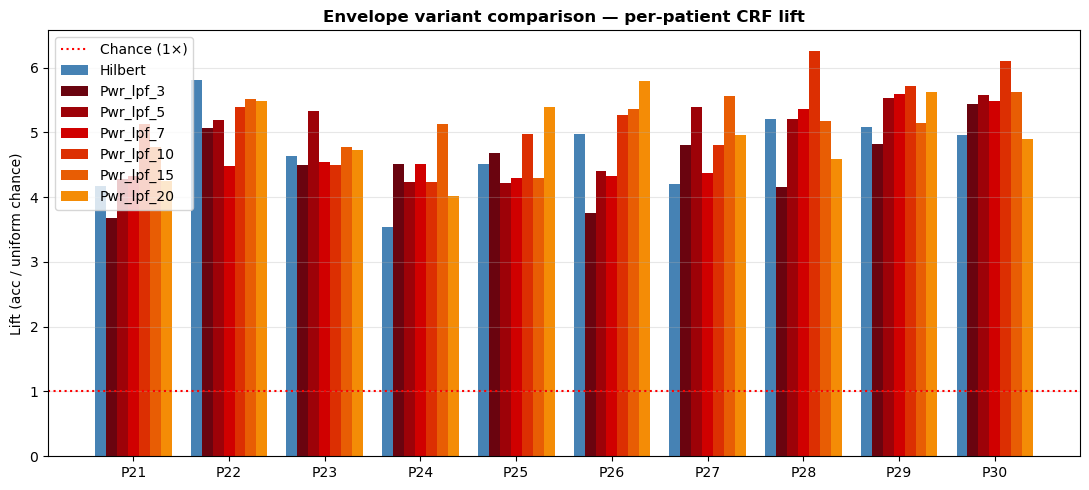


  Saved results to envelope_variants_results_20260427_2015.pkl


In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Bar chart + save raw results
# ═══════════════════════════════════════════════════════════════════════════════


fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(pids))
width = 0.8 / len(variants_to_show)
colors = {'hilbert':     'steelblue',
          'tkeo':        'darkorange',
          'dual':        'seagreen',
          # pwr_lpf cutoffs — colour ramp from dark red (slow) → grey (fast)
          'pwr_lpf_3':   '#6a040f',
          'pwr_lpf_5':   '#9d0208',
          'pwr_lpf_7':   '#d00000',
          'pwr_lpf_10':  '#dc2f02',
          'pwr_lpf_15':  '#e85d04',
          'pwr_lpf_20':  '#f48c06',
          'pwr_lpf_30':  'crimson',
          'pwr_lpf_50':  'mediumpurple',
          'pwr_lpf_100': 'slategray'}

for k, v in enumerate(variants_to_show):
    lifts = [results[v]['per_patient'].get(pid, {}).get('lift', 0) for pid in pids]
    offset = (k - (len(variants_to_show) - 1) / 2) * width
    ax.bar(x + offset, lifts, width,
           color=colors.get(v, 'gray'), label=v.capitalize())

ax.axhline(1.0, color='red', ls=':', lw=1.5, label='Chance (1×)')
ax.set_xticks(x); ax.set_xticklabels(pids, fontsize=10)
ax.set_ylabel('Lift (acc / uniform chance)')
ax.set_title('Envelope variant comparison — per-patient CRF lift',
             fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Save all results to disk
out_path = f'envelope_variants_results_{datetime.now().strftime("%Y%m%d_%H%M")}.pkl'
to_save = {v: {k: r[k] for k in ('variant', 'accs', 'lifts', 'mean_acc',
                                  'mean_lift', 'per_patient')}
           for v, r in results.items()}
with open(out_path, 'wb') as f:
    pickle.dump(to_save, f)
print(f"\n  Saved results to {out_path}")

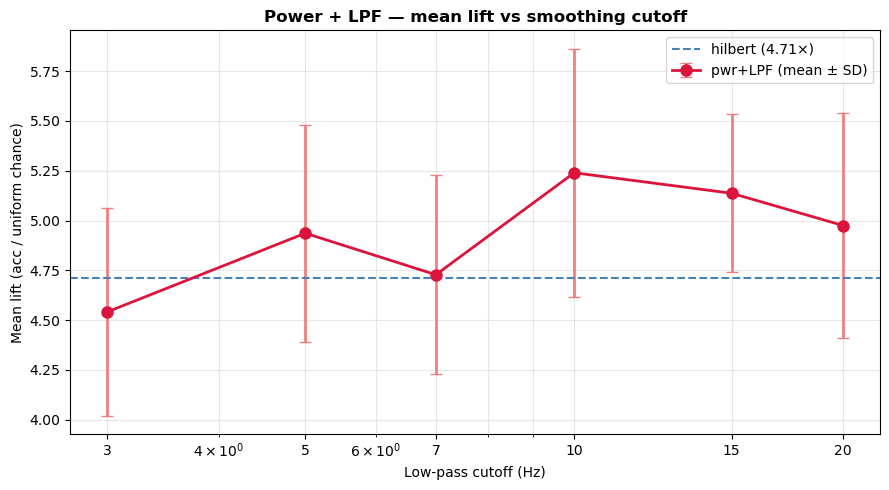


  Cutoff sweep summary:
   cutoff (Hz)   mean lift      ± SD
             3       4.54x  ± 0.52
             5       4.94x  ± 0.55
             7       4.73x  ± 0.50
            10       5.24x  ± 0.62
            15       5.14x  ± 0.40
            20       4.97x  ± 0.56

  Best cutoff: 10 Hz  (lift 5.24x)


In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8b — Cutoff sweep curve (mean lift vs LPF cutoff frequency)
# ═══════════════════════════════════════════════════════════════════════════════
# This is the cleanest read on the sweep: x-axis is the cutoff (log scale),
# y-axis is mean lift, with Hilbert/TKEO/Dual drawn as horizontal reference
# lines for context.

sweep_cutoffs = [3, 5, 7, 10, 15, 20, 30, 50, 100]
sweep_means   = []
sweep_stds    = []
sweep_x       = []
for cut in sweep_cutoffs:
    key = f'pwr_lpf_{cut}'
    if key not in results:
        continue
    sweep_x.append(cut)
    sweep_means.append(results[key]['mean_lift'])
    sweep_stds.append(np.std(results[key]['lifts']))

if sweep_x:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.errorbar(sweep_x, sweep_means, yerr=sweep_stds,
                marker='o', ms=8, lw=2, color='crimson',
                ecolor='lightcoral', capsize=4, label='pwr+LPF (mean ± SD)')

    # Reference horizontals for the non-sweep variants
    for ref, color, ls in [('hilbert', 'steelblue', '--'),
                           ('tkeo',    'darkorange', '--'),
                           ('dual',    'seagreen',  '--')]:
        if ref in results:
            ax.axhline(results[ref]['mean_lift'], color=color, ls=ls, lw=1.5,
                       label=f'{ref} ({results[ref]["mean_lift"]:.2f}×)')

    ax.set_xscale('log')
    ax.set_xticks(sweep_x); ax.set_xticklabels([str(c) for c in sweep_x])
    ax.set_xlabel('Low-pass cutoff (Hz)')
    ax.set_ylabel('Mean lift (acc / uniform chance)')
    ax.set_title('Power + LPF — mean lift vs smoothing cutoff',
                 fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, which='both')
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

    # Also print a tidy summary
    print("\n  Cutoff sweep summary:")
    print(f"  {'cutoff (Hz)':>12}  {'mean lift':>10}  {'± SD':>8}")
    for c, m, s in zip(sweep_x, sweep_means, sweep_stds):
        print(f"  {c:>12}  {m:>9.2f}x  ±{s:>5.2f}")
    best_idx = int(np.argmax(sweep_means))
    print(f"\n  Best cutoff: {sweep_x[best_idx]} Hz  (lift {sweep_means[best_idx]:.2f}x)")


In [26]:
restore_original()

  ✓ extractHG restored to original
